# 02 - Predicting my listening

Two supervised questions, one theme - *what does my listening behaviour give away?*

- **Part A - Will I skip this track?** A clean binary classifier with a built-in label
  (`skipped`). The whole challenge is avoiding leakage and reading *what drives* skips.
- **Part B - Guess the year.** If a model can name the year of a session just from its
  artists, my taste has distinct eras - a tidy way to quantify taste drift.

Both run on the same loaded data; just go top-to-bottom.

In [1]:
import sys
from pathlib import Path

# Make the local package importable without `pip install -e .`
for _p in [Path.cwd(), *Path.cwd().parents]:
    if (_p / "scripts" / "helper_scripts.py").exists():
        sys.path.insert(0, str(_p / "scripts"))
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = ["DejaVu Sans", "Meiryo"]  # CJK fallback for non-Latin artist names
GREEN = "#1DB954"
pd.set_option("display.max_columns", 40)

from helper_scripts import load_streams, clean_streams

df = clean_streams(load_streams())
print(f"{len(df):,} streams loaded:", df["ts"].min().date(), "->", df["ts"].max().date())

172,078 streams loaded: 2019-04-09 -> 2026-04-12


## Part A - Will I skip this track?

The label is `skipped`. The trap is **leakage**: `ms_played` and `reason_end` (e.g.
`fwdbtn`) basically *are* the skip, so they're excluded. I use only what's knowable the
instant a track starts, split by **time** (train on the past, test on the most recent
slice), and care more about interpretation than squeezing accuracy.

### A1. Sessionize

Consecutive plays with gaps under 30 minutes form one listening session. That gives a
position-in-session feature - am I more restless deep into a session?

In [2]:
d = df[df["is_track"]].copy().sort_values("ts").reset_index(drop=True)
gap = d["ts"].diff().dt.total_seconds().fillna(1e9)
d["session_id"] = (gap > 30 * 60).cumsum()
d["session_pos"] = d.groupby("session_id").cumcount()
d["secs_into_session"] = (d["ts"] - d.groupby("session_id")["ts"].transform("min")).dt.total_seconds()
print("sessions:", d["session_id"].nunique(), "| median length:",
      int(d.groupby("session_id").size().median()), "tracks")
d[["ts", "artist", "track", "session_id", "session_pos"]].head()

sessions: 10847 | median length: 6 tracks


,ts,artist,track,session_id,session_pos
0,2019-04-09 06:50:06+00:00,Modest Mouse,Ocean Breathes Salty,1,0
1,2019-04-09 06:50:11+00:00,Many Rooms,Hollow Body,1,1
2,2019-04-09 06:50:12+00:00,Cemeteries,Sodus,1,2
3,2019-04-09 06:50:13+00:00,Modern Baseball,Coals,1,3
4,2019-04-09 06:50:13+00:00,Panucci's Pizza,Naruto Themed Sexting,1,4


### A2. Causal features

Everything here is knowable at play-start. The familiarity counts use `cumcount`, so they
only ever look at the *past* - no peeking at the future.

In [3]:
jst = d["ts"].dt.tz_convert("Asia/Tokyo")
d["hour"] = jst.dt.hour
d["weekday"] = jst.dt.dayofweek
d["is_weekend"] = (d["weekday"] >= 5).astype(int)

# how many times I'd heard this artist / track BEFORE this play
d["artist_plays_before"] = d.groupby("artist", dropna=False).cumcount()
d["track_plays_before"] = d.groupby("spotify_track_uri", dropna=False).cumcount()

for c in ["shuffle", "offline", "incognito_mode"]:
    d[c] = d[c].astype("boolean").fillna(False).astype(int)
d["reason_start"] = d["reason_start"].fillna("unknown").astype(str)
d["platform"] = d["platform"].fillna("unknown").astype(str)

y = d["skipped"].astype("boolean")
mask = y.notna()
d = d[mask].copy()
y = y[mask].astype(int)
d["skip"] = y
print(f"{len(d):,} labelled plays | overall skip rate {y.mean():.1%}")

172,010 labelled plays | overall skip rate 23.7%


### A3. Time-based split

A random split would leak the future into the past for behavioural data, so I train on the
earliest 80% and test on the most recent 20%.

In [4]:
num_cols = ["hour", "weekday", "is_weekend", "session_pos", "secs_into_session",
            "artist_plays_before", "track_plays_before", "shuffle", "offline", "incognito_mode"]
cat_cols = ["reason_start", "platform"]
X = d[num_cols + cat_cols]

split = int(len(d) * 0.8)
Xtr, Xte = X.iloc[:split], X.iloc[split:]
ytr, yte = y.iloc[:split], y.iloc[split:]
print(f"train {len(Xtr):,} (skip {ytr.mean():.1%}) | test {len(Xte):,} (skip {yte.mean():.1%})")
print("test period:", d['ts'].iloc[split].date(), "->", d['ts'].iloc[-1].date())

train 137,608 (skip 14.6%) | test 34,402 (skip 60.1%)
test period: 2024-03-26 -> 2026-04-12


### A4. Model & metrics

`HistGradientBoostingClassifier` (fast, handles mixed types). Because skips are imbalanced
and the rate shifts over time, **PR-AUC** (average precision) is the honest score to beat
the base rate with.

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import average_precision_score, roc_auc_score, classification_report

pre = ColumnTransformer(
    [("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)],
    remainder="passthrough",
)
clf = Pipeline([
    ("pre", pre),
    ("gb", HistGradientBoostingClassifier(max_iter=300, learning_rate=0.08,
                                          max_depth=6, random_state=0)),
])
clf.fit(Xtr, ytr)
proba = clf.predict_proba(Xte)[:, 1]
pred = (proba >= 0.5).astype(int)

print(f"PR-AUC (avg precision): {average_precision_score(yte, proba):.3f}")
print(f"ROC-AUC:                {roc_auc_score(yte, proba):.3f}")
print(f"baseline skip rate:     {yte.mean():.3f}")
print()
print(classification_report(yte, pred, digits=3))

PR-AUC (avg precision): 0.896
ROC-AUC:                0.856
baseline skip rate:     0.601

              precision    recall  f1-score   support

           0      0.756     0.723     0.739     13724
           1      0.821     0.845     0.833     20678

    accuracy                          0.796     34402
   macro avg      0.789     0.784     0.786     34402
weighted avg      0.795     0.796     0.796     34402



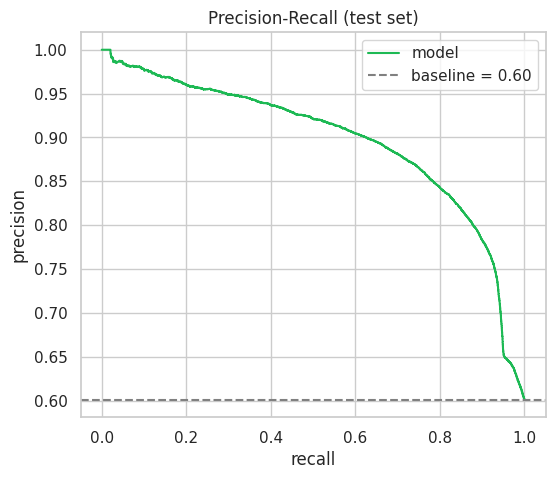

In [6]:
from sklearn.metrics import precision_recall_curve
prec, rec, _ = precision_recall_curve(yte, proba)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(rec, prec, color=GREEN, label="model")
ax.axhline(yte.mean(), ls="--", color="gray", label=f"baseline = {yte.mean():.2f}")
ax.set_xlabel("recall"); ax.set_ylabel("precision")
ax.set_title("Precision-Recall (test set)"); ax.legend()
plt.show()

### A5. What drives my skips?

Permutation importance: shuffle one feature at a time and measure how much PR-AUC drops.
Bigger drop = the model leaned on that feature more.

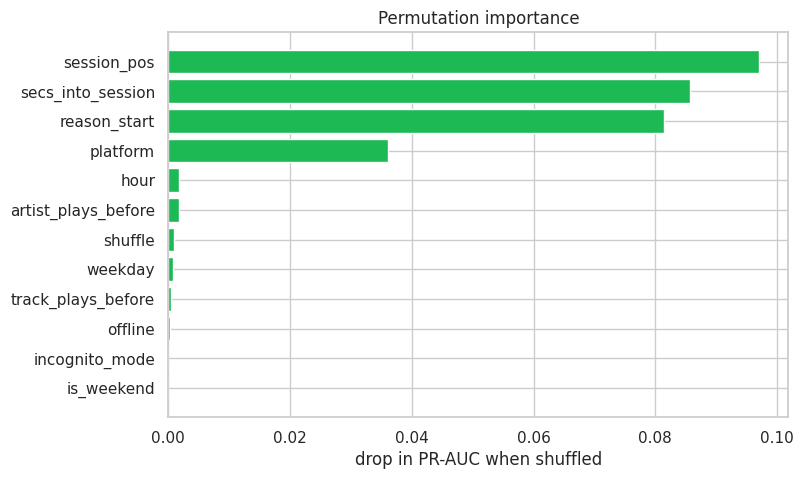

session_pos            0.0970
secs_into_session      0.0856
reason_start           0.0814
platform               0.0361
hour                   0.0018
artist_plays_before    0.0017
shuffle                0.0010
weekday                0.0008
track_plays_before     0.0004
offline                0.0003
is_weekend             0.0000
incognito_mode         0.0000
dtype: float64

In [7]:
from sklearn.inspection import permutation_importance
samp = Xte.sample(min(8000, len(Xte)), random_state=0)
ysamp = yte.loc[samp.index]
imp = permutation_importance(clf, samp, ysamp, n_repeats=5,
                             scoring="average_precision", random_state=0)
imp_s = pd.Series(imp.importances_mean, index=X.columns).sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(imp_s.index, imp_s.values, color=GREEN)
ax.set_xlabel("drop in PR-AUC when shuffled"); ax.set_title("Permutation importance")
plt.show()
imp_s.sort_values(ascending=False).round(4)

### A6. The story behind the model

Two descriptive views that explain *why* those features matter - when I skip in the day,
and where in a session skips cluster.

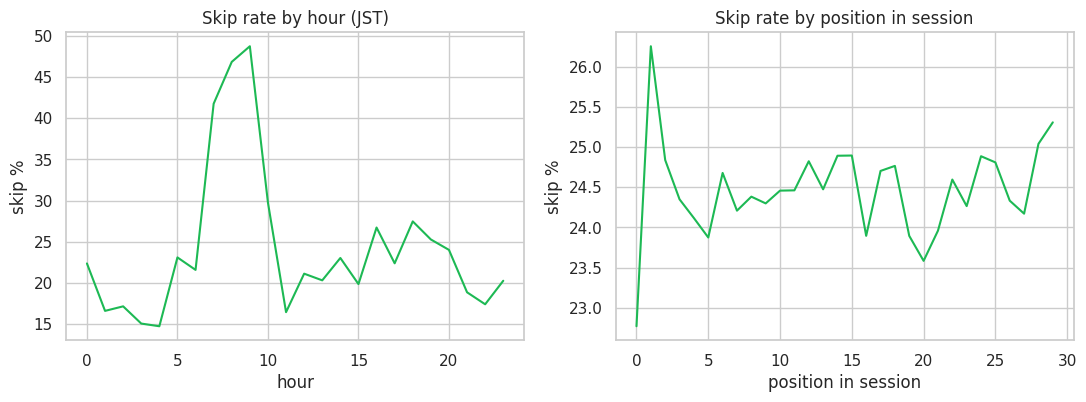

In [8]:
by_hour = d.groupby("hour")["skip"].mean()
by_pos = d[d["session_pos"] < 30].groupby("session_pos")["skip"].mean()
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(by_hour.index, by_hour.values * 100, color=GREEN)
axes[0].set_title("Skip rate by hour (JST)"); axes[0].set_xlabel("hour"); axes[0].set_ylabel("skip %")
axes[1].plot(by_pos.index, by_pos.values * 100, color=GREEN)
axes[1].set_title("Skip rate by position in session"); axes[1].set_xlabel("position in session"); axes[1].set_ylabel("skip %")
plt.show()

## Part B - Guess the year

Different question, same data. Each session becomes a **bag of artists** (TF-IDF), the
label is its year, and a logistic regression guesses the year. If it beats "always guess
my most common year" by a lot, my taste has **distinct, datable eras**. Bonus: the model's
coefficients reveal the most *defining artists* of each year.

### B1. Sessions → bag of artists, labelled by year

In [9]:
d = df[df["is_track"]].dropna(subset=["artist"]).copy().sort_values("ts").reset_index(drop=True)
gap = d["ts"].diff().dt.total_seconds().fillna(1e9)
d["session_id"] = (gap > 30 * 60).cumsum()

yr = d.groupby("session_id")["ts"].first().dt.tz_convert("Asia/Tokyo").dt.year
size = d.groupby("session_id").size()
docs = d.groupby("session_id")["artist"].apply(list)

keep = size[size >= 3].index
docs, ylab = docs.loc[keep], yr.loc[keep]
print(f"{len(docs):,} sessions | years {ylab.min()}-{ylab.max()}")
ylab.value_counts().sort_index()

7,299 sessions | years 2019-2026


ts
2019     964
2020    1224
2021    1123
2022     987
2023    1164
2024     849
2025     784
2026     204
Name: count, dtype: int64

### B2. Vectorize & split

TF-IDF over artists (each artist is a token), dropping artists seen in fewer than 5
sessions. Stratified split so every year appears in train and test.

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

vec = TfidfVectorizer(analyzer=lambda toks: toks, min_df=5)
Xtf = vec.fit_transform(docs.values)
print("artist vocabulary:", len(vec.get_feature_names_out()))

Xtr, Xte, ytr, yte = train_test_split(Xtf, ylab, test_size=0.25, stratify=ylab, random_state=0)
print(f"train {Xtr.shape[0]:,} | test {Xte.shape[0]:,}")

artist vocabulary: 1524
train 5,474 | test 1,825


### B3. Train & evaluate

The bar to beat is "always guess the most common year".

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score

clf = LogisticRegression(max_iter=2000, C=2.0)
clf.fit(Xtr, ytr)
pred = clf.predict(Xte)

baseline = ylab.value_counts(normalize=True).max()
print(f"accuracy:          {accuracy_score(yte, pred):.3f}")
print(f"balanced accuracy: {balanced_accuracy_score(yte, pred):.3f}")
print(f"baseline (most common year): {baseline:.3f}")

accuracy:          0.701
balanced accuracy: 0.676
baseline (most common year): 0.168


### B4. Where it gets confused = how my taste drifts

Row-normalized confusion matrix. Mass on the diagonal = distinct eras; mass *next* to the
diagonal = gradual, year-to-year drift.

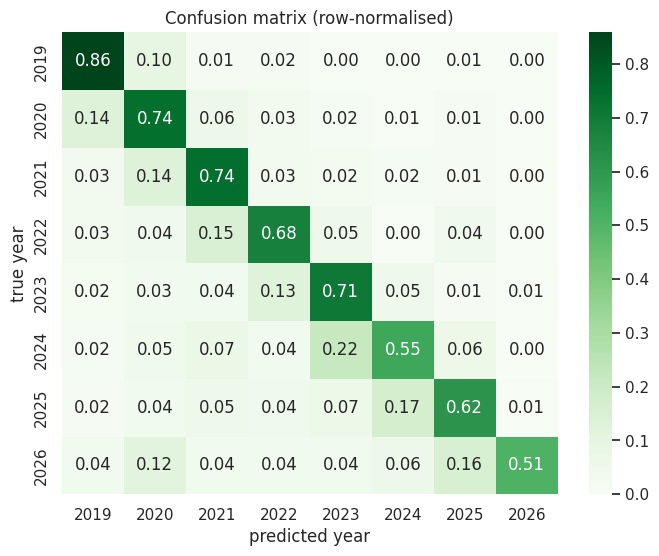

In [12]:
from sklearn.metrics import confusion_matrix
labels = sorted(ylab.unique())
cm = confusion_matrix(yte, pred, labels=labels, normalize="true")
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Greens",
            xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_xlabel("predicted year"); ax.set_ylabel("true year")
ax.set_title("Confusion matrix (row-normalised)")
plt.show()

### B5. The defining artists of each year

The artists whose presence most pushes the model toward each year - basically *the sound
of 20XX* for me.

In [13]:
names = np.array(vec.get_feature_names_out())
print("Most distinctive artists per year:")
for i, year in enumerate(clf.classes_):
    top = names[np.argsort(clf.coef_[i])[::-1][:8]]
    print(f"  {year}: {', '.join(top)}")

Most distinctive artists per year:
  2019: Ski Mask The Slump God, Sonic Youth, Led Zeppelin, Rich Brian, 21 Savage, Avicii, Coldplay, オアシス
  2020: Francis Lai, The Maccabees, Human Tetris, Sidney Bechet, dodie, Forth Wanderers, Chet Baker, Greer
  2021: Mazzy Star, Mac Miller, The Velveteins, George Harrison, Magnolian, Cotton Jones, Beach Fossils, Eric Nakassa
  2022: Peter Cat Recording Co., Steve Lacy, Old Man Canyon, Coma Cinema, Grits, Number Girl, mitsume, Gorgeous Bully
  2023: Ichiko Aoba, Dominic Fike, Twelve Point Buck, 超级市场, Beast Coast, Lily Chou-Chou, Lamp, TAEYANG
  2024: Richy Mitch & The Coal Miners, Mitski, Suki Waterhouse, Drake, Kings of Convenience, The Goo Goo Dolls, Crystal Castles, Father John Misty
  2025: Alex Turner, Космос на потолке, Deftones, The Smashing Pumpkins, наверное радость, ssshhhiiittt!, Travis Bretzer, Kino
  2026: Smerz, 54 Ultra, Jeff Buckley, Haruomi Hosono, my bloody valentine, NIGHT TRAIN, Sade, Olivia Dean


## Takeaways

- **Skips are predictable** from pre-play context alone (PR-AUC well above the base rate).
  The biggest drivers are usually *how the track started* (`reason_start`), *shuffle*, and
  *position in session* - classic "hunting for the right song" behaviour.
- **The year is guessable** from artists far better than chance → my listening has distinct
  yearly signatures, and the confusion matrix shows whether that drift is gradual or abrupt.
- Next: `03_taste_structure.ipynb` looks at the *unsupervised* structure - session modes and
  artist embeddings.

What I like here is that neither model needed anything clever to work. The signal was
already sitting in plain behaviour, which is sort of the whole point: nothing hidden, just
my own clicks. The year classifier surprised me the most, I didn't think "which artists
showed up together" would pin down the year that well.